In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, 
    recall_score, roc_auc_score, ConfusionMatrixDisplay
)

In [4]:
np.random.seed(1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def initialize_parameters(layers_dims):
    parameters = {}
    L = len(layers_dims)
    for l in range(1, L):
        parameters["W" + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2 / layers_dims[l-1])
        parameters["b" + str(l)] = np.zeros((layers_dims[l], 1))
    return parameters


In [5]:
def forward_propagation(X, parameters, dropout_rate=0):
    cache = {}
    A = X.T  # Input shape: (n_x, m)
    cache["A0"] = A
    L = len(parameters) // 2  # number of layers...
    for l in range(1, L + 1):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        Z = np.dot(W, A) + b
        cache["Z" + str(l)] = Z
        
        if l == L:
            # Output layer uses sigmoid for binary classification
            A = sigmoid(Z)
        else:
            A = relu(Z)
            
            if dropout_rate > 0:
                D = (np.random.rand(*A.shape) < (1 - dropout_rate)).astype(float)
                A = A * D
                A = A / (1 - dropout_rate)  
                cache["D" + str(l)] = D
        cache["A" + str(l)] = A
    return A, cache



In [6]:
def compute_cost(AL, Y, parameters, lambda_l1=0, lambda_l2=0):
    m = Y.shape[0]
    AL = np.clip(AL, 1e-8, 1 - 1e-8)  # avoid log(0)
    cost = -np.sum(Y.T * np.log(AL) + (1 - Y.T) * np.log(1 - AL)) / m
    
    L = len(parameters) // 2
    reg_cost = 0
    for l in range(1, L + 1):
        W = parameters["W" + str(l)]
        if lambda_l2:
            reg_cost += (lambda_l2 / 2) * np.sum(np.square(W))
        if lambda_l1:
            reg_cost += (lambda_l1) * np.sum(np.abs(W))
    cost += reg_cost / m
    return cost


In [11]:
def backward_propagation(X, Y, cache, parameters, lambda_l1=0, lambda_l2=0, dropout_rate=0):
    grads = {}
    m = X.shape[0]
    L = len(parameters) // 2
    Y = Y.reshape(1, m)
    
    AL = cache["A" + str(L)]
    dZ = AL - Y
    
    for l in reversed(range(1, L + 1)):
        A_prev = cache["A" + str(l - 1)]
        W = parameters["W" + str(l)]
        dW = (1 / m) * np.dot(dZ, A_prev.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        
        if lambda_l2:
            dW += (lambda_l2 / m) * W
        if lambda_l1:
            dW += (lambda_l1 / m) * np.sign(W)
            
        grads["dW" + str(l)] = dW
        grads["db" + str(l)] = db
        
        if l > 1:
            dA_prev = np.dot(W.T, dZ)
            
            if dropout_rate > 0:
                D = cache.get("D" + str(l - 1), np.ones_like(dA_prev))
                dA_prev = dA_prev * D
                dA_prev = dA_prev / (1 - dropout_rate)
            Z_prev = cache["Z" + str(l - 1)]
            dZ = dA_prev * relu_deriv(Z_prev)
    return grads


In [13]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]
    return parameters


In [15]:
def train_model(X, Y, X_val, Y_val, layers_dims, learning_rate=0.01, num_epochs=300,
                lambda_l1=0, lambda_l2=0, dropout_rate=0, print_cost=False):
    parameters = initialize_parameters(layers_dims)
    history = {
        "costs": [],
        "val_costs": [],
        "train_accuracies": [],
        "val_accuracies": []
    }
    m = X.shape[0]
    
    for epoch in range(num_epochs):
        # Forward propagation with dropout (only during training)
        AL, cache = forward_propagation(X, parameters, dropout_rate)
        cost = compute_cost(AL, Y, parameters, lambda_l1, lambda_l2)
        
        # Backward propagation
        grads = backward_propagation(X, Y, cache, parameters, lambda_l1, lambda_l2, dropout_rate)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Compute training accuracy
        predictions_train = (AL > 0.5).astype(int)
        acc_train = np.mean(predictions_train == Y.T)
        
        # Compute validation performance (without dropout)
        AL_val, _ = forward_propagation(X_val, parameters, dropout_rate=0)
        cost_val = compute_cost(AL_val, Y_val, parameters, lambda_l1, lambda_l2)
        predictions_val = (AL_val > 0.5).astype(int)
        acc_val = np.mean(predictions_val == Y_val.T)
        
        history["costs"].append(cost)
        history["val_costs"].append(cost_val)
        history["train_accuracies"].append(acc_train)
        history["val_accuracies"].append(acc_val)
        
        if print_cost and epoch % 100 == 0:
            print(f"Epoch {epoch}: cost = {cost:.4f}, val_cost = {cost_val:.4f}, train_acc = {acc_train:.4f}, val_acc = {acc_val:.4f}")
    
    return parameters, history



In [17]:
def predict(X, parameters):
    AL, _ = forward_propagation(X, parameters, dropout_rate=0)
    predictions = (AL > 0.5).astype(int)
    return predictions.T, AL


In [23]:
data = load_breast_cancer()
X = data.data            # shape: (n_samples, n_features)
Y = data.target.reshape(-1, 1)  # shape: (n_samples, 1)

print(f"No of samples,features : {X.shape}")

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

n_x = X_train.shape[1]  
layers_dims = [n_x, 32, 16, 1]

{
    "Baseline": {"lambda_l1": 0,      "lambda_l2": 0,      "dropout_rate": 0},
    "L1":       {"lambda_l1": 0.001,  "lambda_l2": 0,      "dropout_rate": 0},
    "L2":       {"lambda_l1": 0,      "lambda_l2": 0.001,  "dropout_rate": 0},
    "Dropout":  {"lambda_l1": 0,      "lambda_l2": 0,      "dropout_rate": 0.2},
    "L1+L2":   {"lambda_l1": 0.001,  "lambda_l2": 0.001,  "dropout_rate": 0},
    "L1+Dropout": {"lambda_l1": 0.001, "lambda_l2": 0,     "dropout_rate": 0.2},
    "L2+Dropout": {"lambda_l1": 0,     "lambda_l2": 0.001, "dropout_rate": 0.2},
    "L1+L2+Dropout": {"lambda_l1": 0.001, "lambda_l2": 0.001, "dropout_rate": 0.2},
}



No of samples,features : (569, 30)


In [21]:
results = {}

for exp_name, reg_params in experiments.items():
    print(f"Training experiment: {exp_name}")
    
    parameters, history = train_model(
        X_train, Y_train, X_val, Y_val,
        layers_dims=layers_dims,
        learning_rate=0.01,
        num_epochs=300,
        lambda_l1=reg_params["lambda_l1"],
        lambda_l2=reg_params["lambda_l2"],
        dropout_rate=reg_params["dropout_rate"],
        print_cost=False
    )
    
    Y_pred_test, AL_test = predict(X_test, parameters)
    cm = confusion_matrix(Y_test, Y_pred_test)
    f1 = f1_score(Y_test, Y_pred_test)
    precision = precision_score(Y_test, Y_pred_test)
    recall = recall_score(Y_test, Y_pred_test)
    roc_auc = roc_auc_score(Y_test, AL_test.T)
    
    results[exp_name] = {
        "history": history,
        "confusion_matrix": cm,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
    }
    print(f"{exp_name} Test Metrics -- F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, ROC AUC: {roc_auc:.4f}\n")



Training experiment: Baseline
Baseline Test Metrics -- F1: 0.9487, Precision: 0.9250, Recall: 0.9737, ROC AUC: 0.9868

Training experiment: L1
L1 Test Metrics -- F1: 0.9673, Precision: 0.9610, Recall: 0.9737, ROC AUC: 0.9945

Training experiment: L2
L2 Test Metrics -- F1: 0.9669, Precision: 0.9733, Recall: 0.9605, ROC AUC: 0.9952

Training experiment: Dropout
Dropout Test Metrics -- F1: 0.9412, Precision: 0.9351, Recall: 0.9474, ROC AUC: 0.9557

Training experiment: L1+L2
L1+L2 Test Metrics -- F1: 0.9673, Precision: 0.9610, Recall: 0.9737, ROC AUC: 0.9972

Training experiment: L1+Dropout
L1+Dropout Test Metrics -- F1: 0.9669, Precision: 0.9733, Recall: 0.9605, ROC AUC: 0.9848

Training experiment: L2+Dropout
L2+Dropout Test Metrics -- F1: 0.9600, Precision: 0.9730, Recall: 0.9474, ROC AUC: 0.9934

Training experiment: L1+L2+Dropout
L1+L2+Dropout Test Metrics -- F1: 0.9673, Precision: 0.9610, Recall: 0.9737, ROC AUC: 0.9879



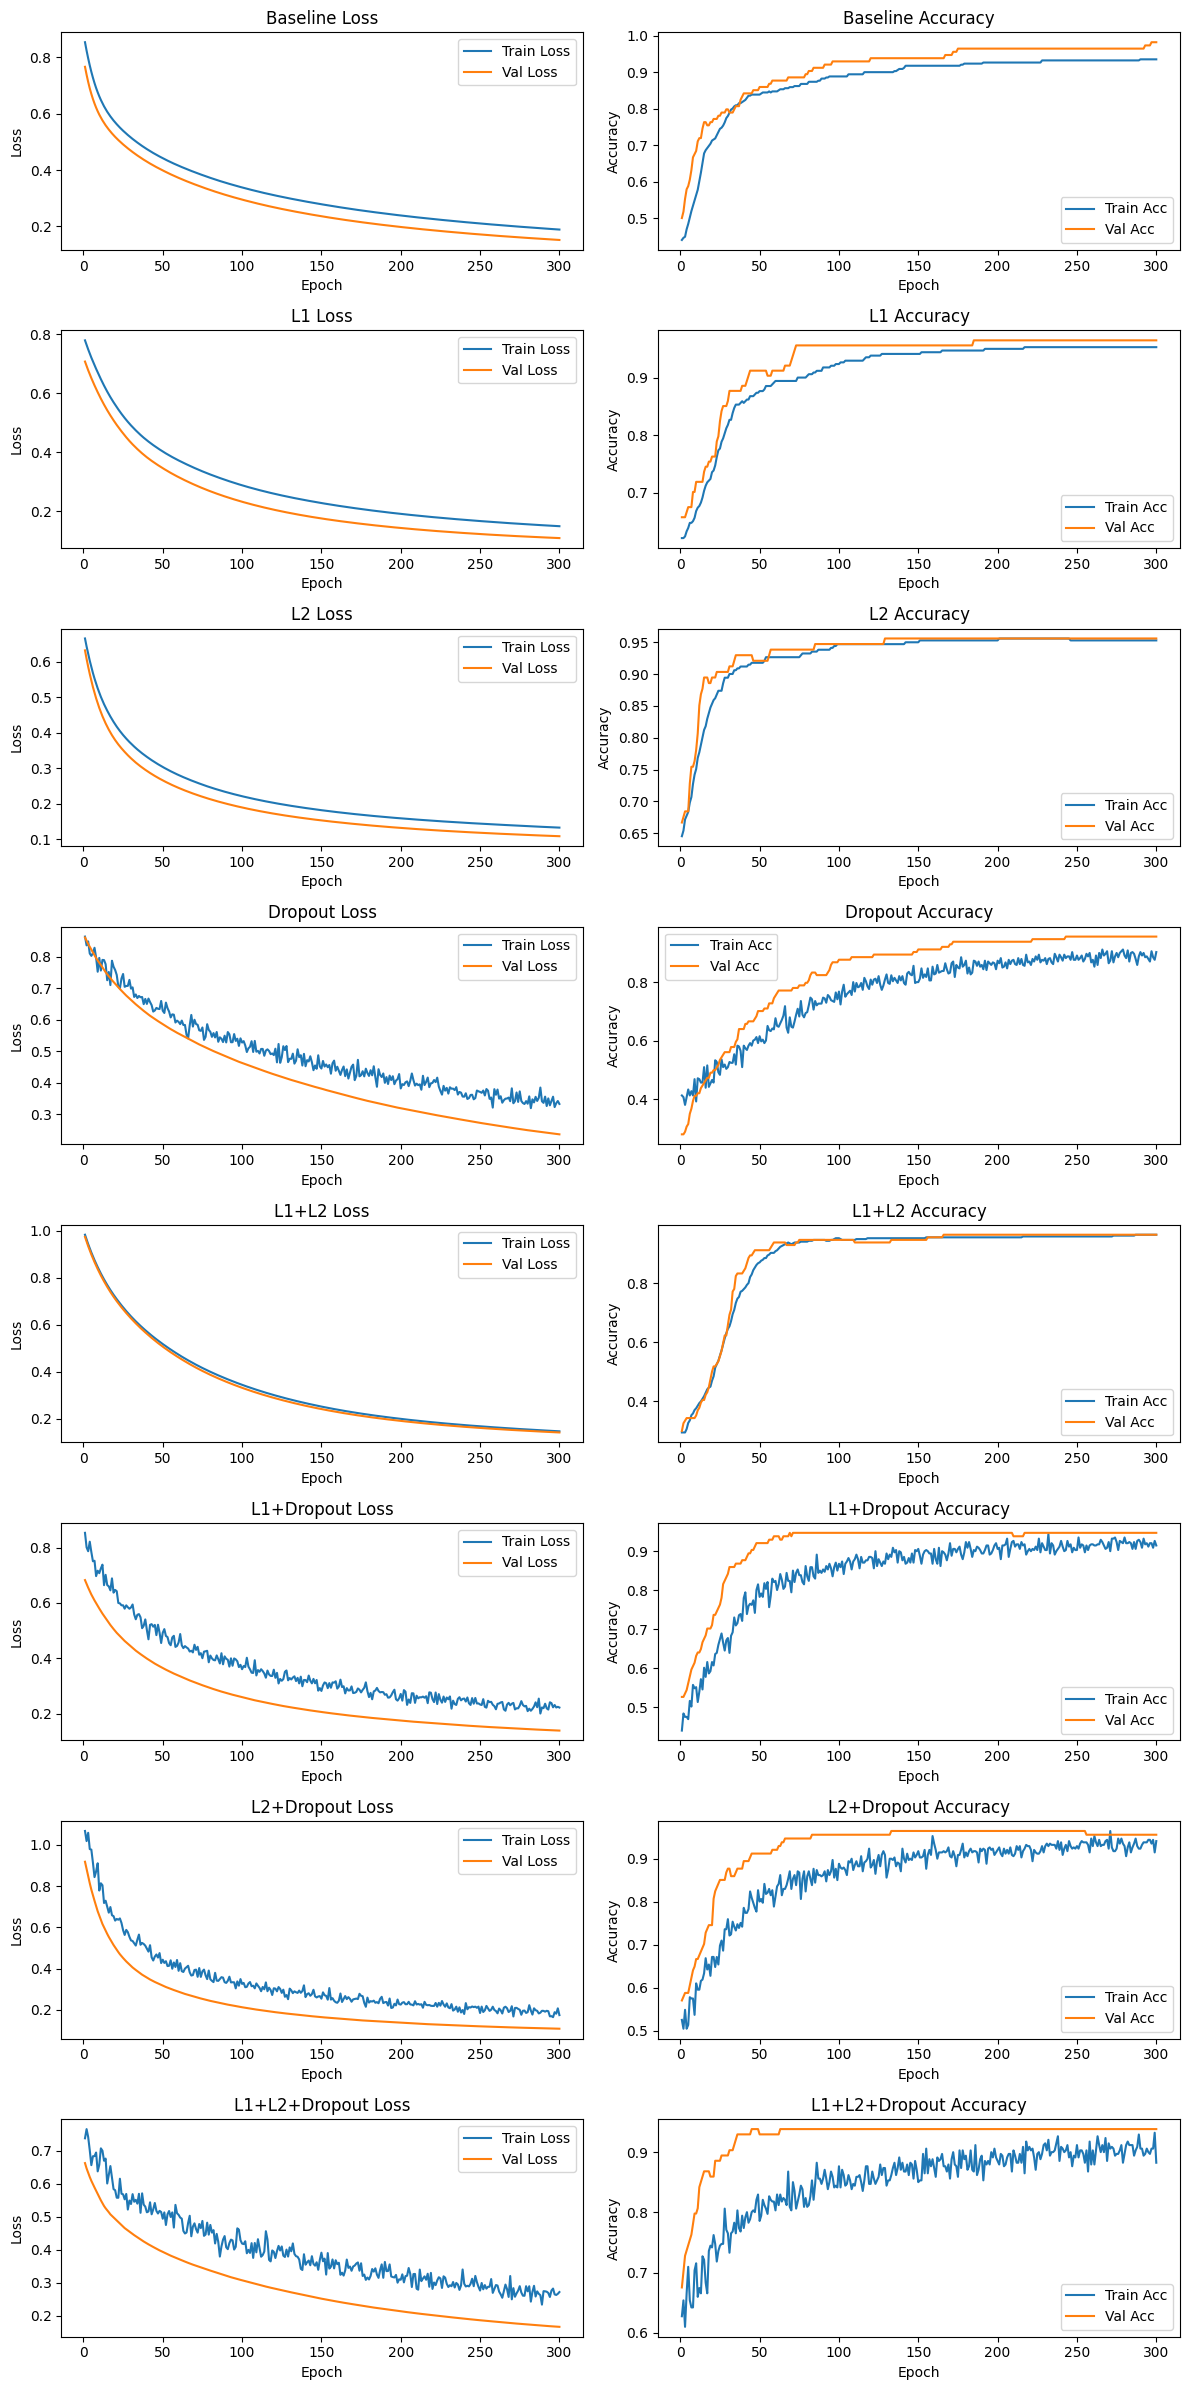

Experiment: Baseline
Confusion Matrix:
[[32  6]
 [ 2 74]]
F1 Score: 0.9487
Precision: 0.9250
Recall: 0.9737
ROC AUC: 0.9868


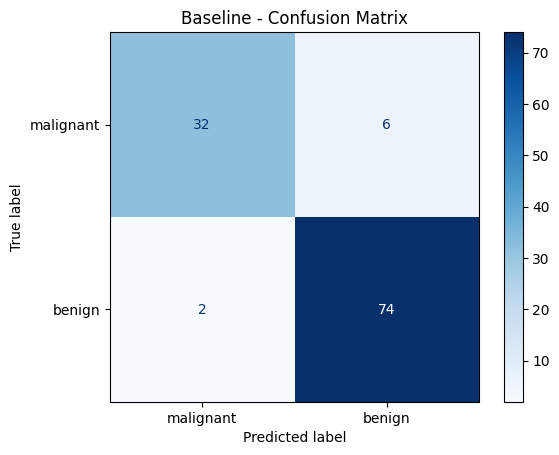

Experiment: L1
Confusion Matrix:
[[35  3]
 [ 2 74]]
F1 Score: 0.9673
Precision: 0.9610
Recall: 0.9737
ROC AUC: 0.9945


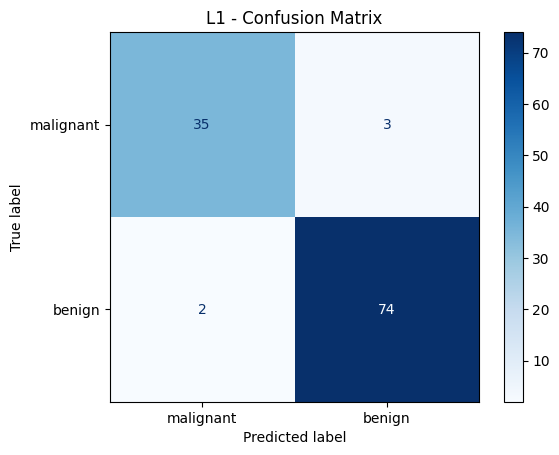

Experiment: L2
Confusion Matrix:
[[36  2]
 [ 3 73]]
F1 Score: 0.9669
Precision: 0.9733
Recall: 0.9605
ROC AUC: 0.9952


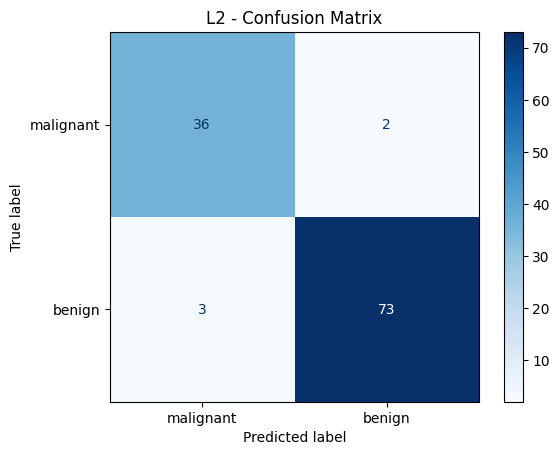

Experiment: Dropout
Confusion Matrix:
[[33  5]
 [ 4 72]]
F1 Score: 0.9412
Precision: 0.9351
Recall: 0.9474
ROC AUC: 0.9557


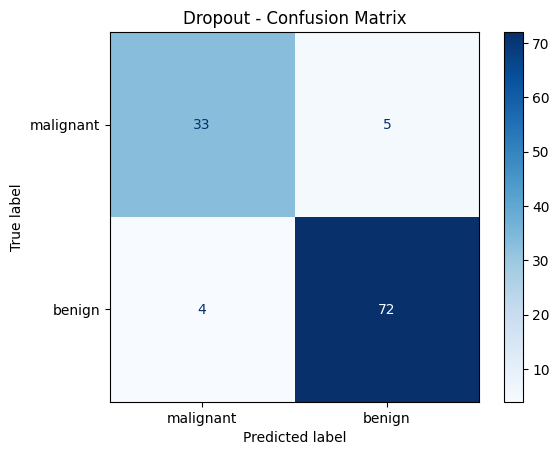

Experiment: L1+L2
Confusion Matrix:
[[35  3]
 [ 2 74]]
F1 Score: 0.9673
Precision: 0.9610
Recall: 0.9737
ROC AUC: 0.9972


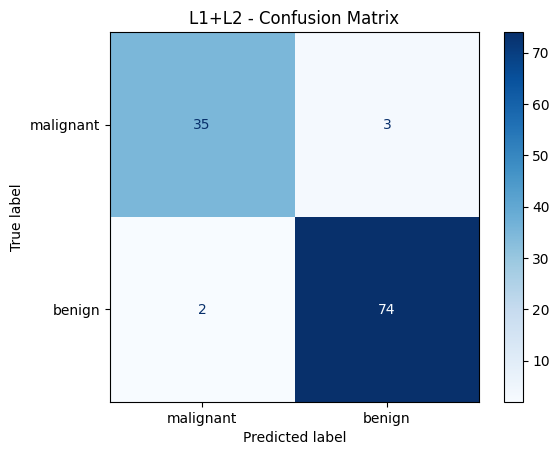

Experiment: L1+Dropout
Confusion Matrix:
[[36  2]
 [ 3 73]]
F1 Score: 0.9669
Precision: 0.9733
Recall: 0.9605
ROC AUC: 0.9848


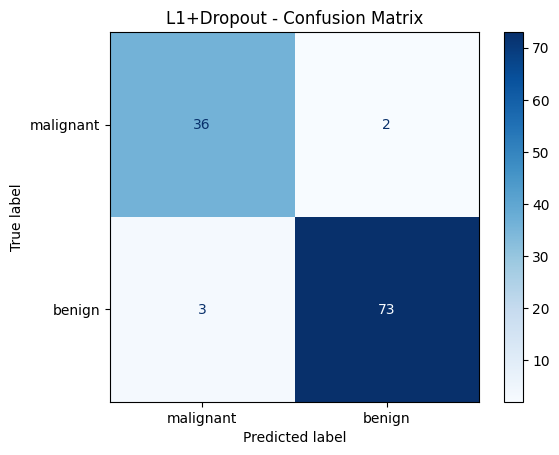

Experiment: L2+Dropout
Confusion Matrix:
[[36  2]
 [ 4 72]]
F1 Score: 0.9600
Precision: 0.9730
Recall: 0.9474
ROC AUC: 0.9934


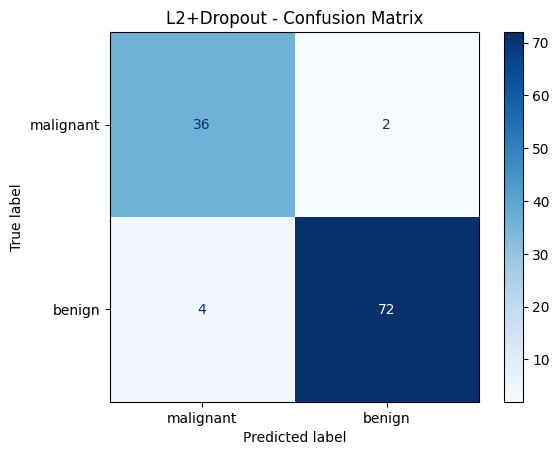

Experiment: L1+L2+Dropout
Confusion Matrix:
[[35  3]
 [ 2 74]]
F1 Score: 0.9673
Precision: 0.9610
Recall: 0.9737
ROC AUC: 0.9879


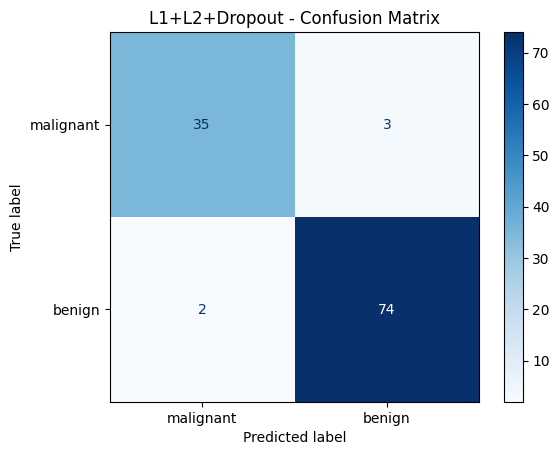

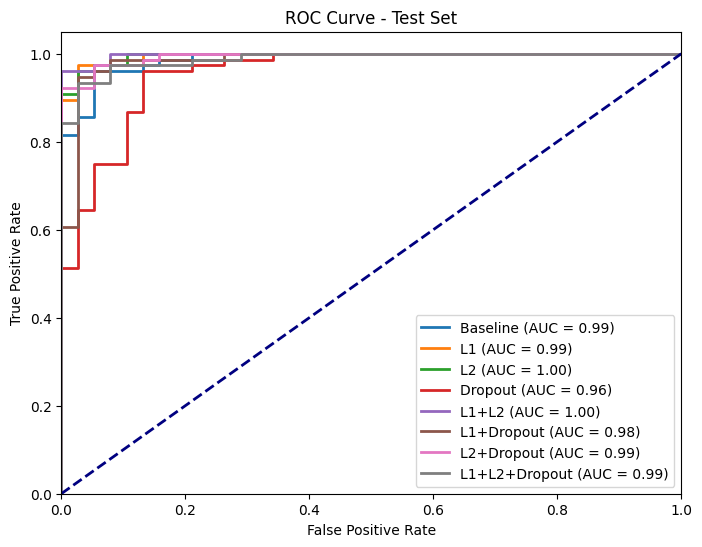

In [27]:
# Plot training and validation loss and accuracy curves for each experiment
num_experiments = len(experiments)
fig, axs = plt.subplots(num_experiments, 2, figsize=(12, num_experiments * 3))
if num_experiments == 1:
    axs = np.expand_dims(axs, axis=0)

for i, (exp_name, result) in enumerate(results.items()):
    history = result["history"]
    epochs = range(1, len(history["costs"]) + 1)
    
    # Plot Loss
    axs[i, 0].plot(epochs, history["costs"], label="Train Loss")
    axs[i, 0].plot(epochs, history["val_costs"], label="Val Loss")
    axs[i, 0].set_title(f"{exp_name} Loss")
    axs[i, 0].set_xlabel("Epoch")
    axs[i, 0].set_ylabel("Loss")
    axs[i, 0].legend()
    
    # Plot Accuracy
    axs[i, 1].plot(epochs, history["train_accuracies"], label="Train Acc")
    axs[i, 1].plot(epochs, history["val_accuracies"], label="Val Acc")
    axs[i, 1].set_title(f"{exp_name} Accuracy")
    axs[i, 1].set_xlabel("Epoch")
    axs[i, 1].set_ylabel("Accuracy")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

# Visualize test set performance for each experiment (confusion matrix and metrics)
for exp_name, result in results.items():
    cm = result["confusion_matrix"]
    print(f"Experiment: {exp_name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"F1 Score: {result['f1_score']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall: {result['recall']:.4f}")
    print(f"ROC AUC: {result['roc_auc']:.4f}")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{exp_name} - Confusion Matrix")
    plt.show()

# Plot ROC curves for each experiment on the test set
plt.figure(figsize=(8, 6))
for exp_name, result in results.items():
    AL_test = result["AL_test"]  # Shape: (1, m)
    # Compute ROC curve from true labels and predicted probabilities
    fpr, tpr, _ = roc_curve(Y_test, AL_test.flatten())
    roc_auc_curve = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{exp_name} (AUC = {roc_auc_curve:.2f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()

